In [1]:


# ================================================================
# BLOQUE 1: IMPORTS GENERALES Y CONFIGURACIÓN
# ================================================================
import os
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler, random_split
from torchvision import datasets, models, transforms
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import time, copy
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# ================================================================
# BLOQUE 2: RUTAS A DATASETS
# ================================================================

trashnet_dir = r"D:\Documentos\IPN\6to Semestre\Metodologia_de_la_investigacion\Clasificacion_residuos\data_preprocessed\ResNet18\TrashNet"
taco_dir     = r"D:\Documentos\IPN\6to Semestre\Metodologia_de_la_investigacion\Clasificacion_residuos\data_preprocessed\ResNet18\TACO"

output_dir = r"D:\Documentos\IPN\6to Semestre\Metodologia_de_la_investigacion\Clasificacion_residuos\Programas\ResNet\Modelos_experimentos"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ================================================================
# BLOQUE 3: FUNCIONES AUXILIARES
# ================================================================

def split_stratified(dataset, train_ratio=0.7, val_ratio=0.15, seed=42):
    np.random.seed(seed)
    targets = np.array(dataset.targets)
    classes = np.unique(targets)
    
    train_idx, val_idx, test_idx = [], [], []
    for c in classes:
        c_idx = np.where(targets == c)[0]
        np.random.shuffle(c_idx)
        n_total = len(c_idx)
        n_train = int(train_ratio * n_total)
        n_val = int(val_ratio * n_total)
        
        train_idx += list(c_idx[:n_train])
        val_idx   += list(c_idx[n_train:n_train+n_val])
        test_idx  += list(c_idx[n_train+n_val:])
    
    return train_idx, val_idx, test_idx


def make_balanced_sampler(subset, full_dataset):
    targets = np.array(full_dataset.targets)
    subset_targets = targets[subset.indices]
    class_counts = Counter(subset_targets)
    weights = {cls: 1.0/count for cls, count in class_counts.items()}
    sample_weights = [weights[label] for label in subset_targets]
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

In [4]:
# ================================================================
# BLOQUE 4: FUNCIÓN DE ENTRENAMIENTO CON HISTORIAL PARA CURVAS
# ================================================================

def train_model(model, criterion, optimizer, dataloaders, dataset_sizes,
                num_epochs=20, patience=4, save_name="modelo.pth"):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    since = time.time()
    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    no_improve = 0

    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch+1}/{num_epochs}")
        print("-" * 50)

        for phase in ["train", "val"]:
            model.train() if phase=="train" else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=="train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase=="train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item()*inputs.size(0)
                running_corrects += torch.sum(preds==labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects.double()/dataset_sizes[phase]

            print(f"{phase.upper()} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            # registrar historial
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())

            # early stopping
            if phase == "val":
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_wts = copy.deepcopy(model.state_dict())
                    no_improve = 0
                else:
                    no_improve += 1

        if no_improve >= patience:
            print("\nEARLY STOPPING activado")
            break

    model.load_state_dict(best_wts)
    torch.save(model.state_dict(), os.path.join(output_dir, save_name))

    print(f"\nMejor ACC validación: {best_acc:.4f}")
    return model, history

In [5]:
# ================================================================
# BLOQUE 5: FUNCIÓN PARA GRAFICAR CURVAS DE APRENDIZAJE
# ================================================================

def plot_curves(history, title="Curvas de aprendizaje"):
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Épocas")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.title(title + " - Accuracy")
    plt.xlabel("Épocas")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [6]:
# ================================================================
# FUNCIÓN DE EVALUACIÓN COMPLETA
# Matriz de confusión (gráfica) + metrics por defecto en consola
# ================================================================

def evaluar_en_test(model, loader, class_names, modelo_nombre="Modelo"):
    model.eval()
    all_preds, all_labels = [], []

    # 1. Recolectar predicciones reales vs predichas
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ===========================================================
    # 2. Reporte de clasificación (texto)
    # ===========================================================
    print("\n===============================================")
    print(f"   REPORTES DE EVALUACIÓN - {modelo_nombre}")
    print("===============================================\n")

    print(classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=3
    ))

    # ===========================================================
    # 3. Matriz de confusión (gráfica)
    # ===========================================================

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(7,6))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Matriz de Confusión - {modelo_nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Etiqueta Real")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
    plt.yticks(np.arange(len(class_names)), class_names)

    # valores dentro de celdas
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

    plt.colorbar()
    plt.tight_layout()
    plt.show()

    # ===========================================================
    # 4. Exactitud total
    # ===========================================================
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"Exactitud global en TEST ({modelo_nombre}): {acc:.4f}")

    return acc

Clases TrashNet: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Época 1/10
--------------------------------------------------
TRAIN | Loss: 1.4092 | Acc: 0.4648
VAL | Loss: 1.1193 | Acc: 0.6005

Época 2/10
--------------------------------------------------
TRAIN | Loss: 0.9594 | Acc: 0.6842
VAL | Loss: 0.9351 | Acc: 0.6622

Época 3/10
--------------------------------------------------
TRAIN | Loss: 0.7861 | Acc: 0.7479
VAL | Loss: 0.8438 | Acc: 0.6863

Época 4/10
--------------------------------------------------
TRAIN | Loss: 0.6966 | Acc: 0.7840
VAL | Loss: 0.7457 | Acc: 0.7158

Época 5/10
--------------------------------------------------
TRAIN | Loss: 0.6452 | Acc: 0.7857
VAL | Loss: 0.7237 | Acc: 0.7105

Época 6/10
--------------------------------------------------
TRAIN | Loss: 0.5714 | Acc: 0.8304
VAL | Loss: 0.6977 | Acc: 0.7507

Época 7/10
--------------------------------------------------
TRAIN | Loss: 0.5442 | Acc: 0.8269
VAL | Loss: 0.6851 | Acc: 0.7560

Époc

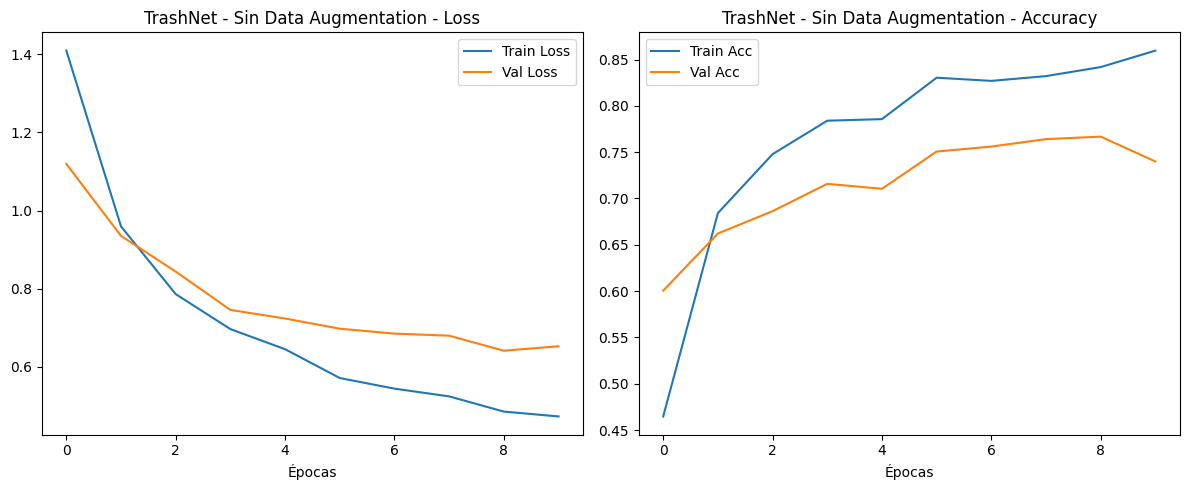

In [7]:
# ================================================================
# BLOQUE 6: ENTRENAMIENTO TRASHNET - SIN DATA AUGMENTATION
# ================================================================

transform = transforms.ToTensor()
trashnet_full = datasets.ImageFolder(trashnet_dir, transform=transform)
print("Clases TrashNet:", trashnet_full.classes)

train_idx, val_idx, test_idx = split_stratified(trashnet_full)
train_ds = Subset(trashnet_full, train_idx)
val_ds   = Subset(trashnet_full, val_idx)
test_ds  = Subset(trashnet_full, test_idx)

sampler  = make_balanced_sampler(train_ds, trashnet_full)

batch = 32
train_loader = DataLoader(train_ds, batch_size=batch, sampler=sampler)
val_loader   = DataLoader(val_ds, batch_size=batch)
test_loader  = DataLoader(test_ds, batch_size=batch)

dataloaders = {"train": train_loader, "val": val_loader}
dataset_sizes = {"train": len(train_ds), "val": len(val_ds)}

# --- MODELO ---
model_tn = models.resnet18(weights="IMAGENET1K_V1")
for p in model_tn.parameters():
    p.requires_grad = True

model_tn.fc = nn.Linear(model_tn.fc.in_features, len(trashnet_full.classes))
model_tn = model_tn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tn.fc.parameters(), lr=1e-3)

model_tn, hist_tn = train_model(
    model_tn, criterion, optimizer,
    dataloaders, dataset_sizes,
    num_epochs=10, patience=4,
    save_name="resnet18_trashnet_pretrain.pth"
)

plot_curves(hist_tn, "TrashNet - Sin Data Augmentation")


Época 1/10
--------------------------------------------------
TRAIN | Loss: 1.3659 | Acc: 0.4900
VAL | Loss: 1.0389 | Acc: 0.6524

Época 2/10
--------------------------------------------------
TRAIN | Loss: 0.9006 | Acc: 0.7147
VAL | Loss: 0.8058 | Acc: 0.7219

Época 3/10
--------------------------------------------------
TRAIN | Loss: 0.7806 | Acc: 0.7381
VAL | Loss: 0.7107 | Acc: 0.7540

Época 4/10
--------------------------------------------------
TRAIN | Loss: 0.6713 | Acc: 0.7804
VAL | Loss: 0.6699 | Acc: 0.7727

Época 5/10
--------------------------------------------------
TRAIN | Loss: 0.6030 | Acc: 0.8125
VAL | Loss: 0.6345 | Acc: 0.7807

Época 6/10
--------------------------------------------------
TRAIN | Loss: 0.5870 | Acc: 0.8067
VAL | Loss: 0.6125 | Acc: 0.7888

Época 7/10
--------------------------------------------------
TRAIN | Loss: 0.5367 | Acc: 0.8256
VAL | Loss: 0.6012 | Acc: 0.7754

Época 8/10
--------------------------------------------------
TRAIN | Loss: 0.5122

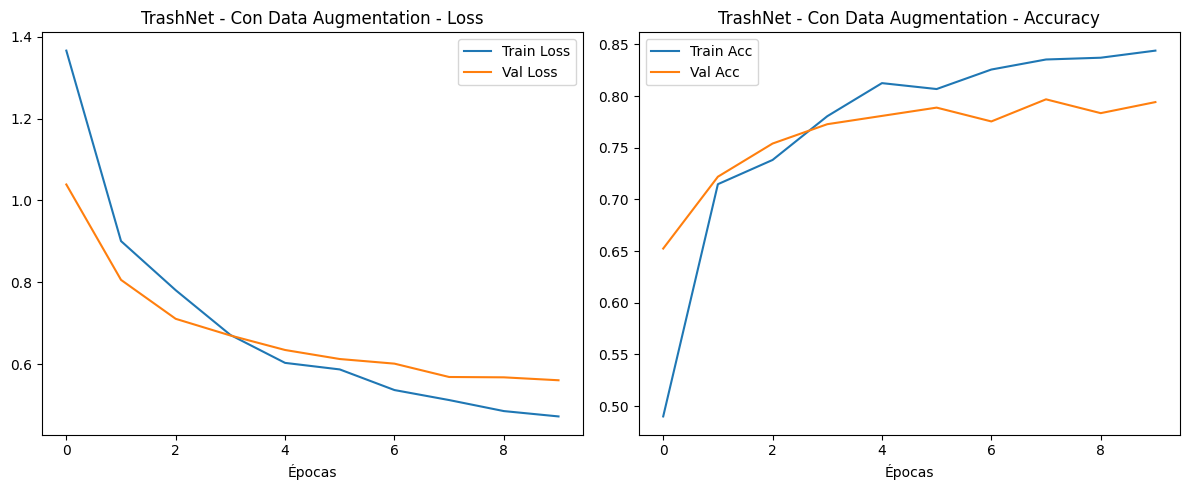

In [9]:
# ================================================================
# BLOQUE 7: ENTRENAMIENTO TRASHNET - CON DATA AUGMENTATION
# ================================================================

train_transform_tn = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor()
])

base_transform_tn = transforms.ToTensor()

trashnet_aug_full = datasets.ImageFolder(trashnet_dir, transform=train_transform_tn)

# split reproducible
train_size = int(0.7 * len(trashnet_aug_full))
val_size   = int(0.15 * len(trashnet_aug_full))
test_size  = len(trashnet_aug_full) - train_size - val_size

torch.manual_seed(42)
train_ds_aug, val_ds_aug, test_ds_aug = random_split(
    trashnet_aug_full, [train_size, val_size, test_size]
)

# para validación y test: sin augmentación
val_ds_aug.dataset.transform  = base_transform_tn
test_ds_aug.dataset.transform = base_transform_tn

train_loader_aug = DataLoader(train_ds_aug, batch_size=32, shuffle=True)
val_loader_aug   = DataLoader(val_ds_aug, batch_size=32)
test_loader_aug  = DataLoader(test_ds_aug, batch_size=32)

dataloaders_aug = {"train": train_loader_aug, "val": val_loader_aug}
dataset_sizes_aug = {"train": len(train_ds_aug), "val": len(val_ds_aug)}

# Modelo
model_tn_aug = models.resnet18(weights="IMAGENET1K_V1")
for p in model_tn_aug.parameters():
    p.requires_grad = True

model_tn_aug.fc = nn.Linear(model_tn_aug.fc.in_features, len(trashnet_aug_full.classes))
model_tn_aug = model_tn_aug.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tn_aug.fc.parameters(), lr=1e-3)

model_tn_aug, hist_tn_aug = train_model(
    model_tn_aug, criterion, optimizer,
    dataloaders_aug, dataset_sizes_aug,
    num_epochs=10, patience=4,
    save_name="resnet18_trashnet_aug_pretrain.pth"
)

plot_curves(hist_tn_aug, "TrashNet - Con Data Augmentation")



=== EVALUACIÓN TrashNet - SIN DA ===

   REPORTES DE EVALUACIÓN - TrashNet - Sin DA

              precision    recall  f1-score   support

   cardboard      0.962     0.820     0.885        61
       glass      0.699     0.671     0.685        76
       metal      0.746     0.758     0.752        62
       paper      0.888     0.908     0.898        87
     plastic      0.711     0.740     0.725        73
       trash      0.607     0.773     0.680        22

    accuracy                          0.782       381
   macro avg      0.769     0.778     0.771       381
weighted avg      0.789     0.782     0.784       381



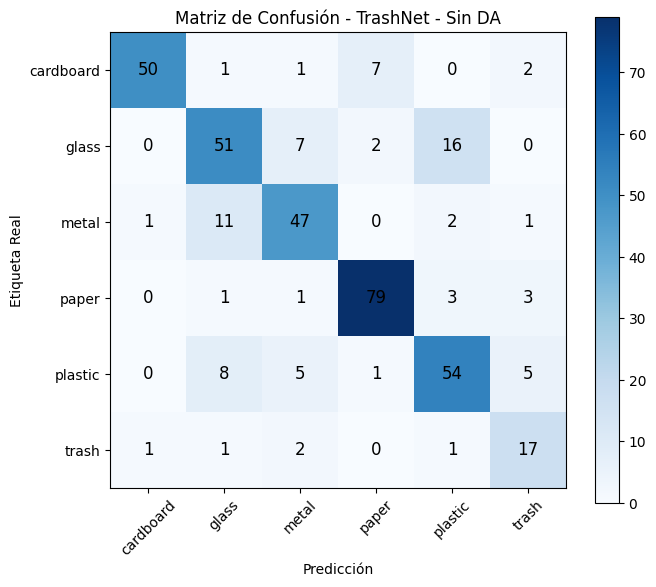

Exactitud global en TEST (TrashNet - Sin DA): 0.7822

=== EVALUACIÓN TrashNet - CON DA ===

   REPORTES DE EVALUACIÓN - TrashNet - Con DA

              precision    recall  f1-score   support

   cardboard      0.946     0.914     0.930        58
       glass      0.840     0.700     0.764        90
       metal      0.690     0.755     0.721        53
       paper      0.867     0.889     0.878        81
     plastic      0.729     0.849     0.785        73
       trash      0.684     0.619     0.650        21

    accuracy                          0.806       376
   macro avg      0.793     0.788     0.788       376
weighted avg      0.811     0.806     0.806       376



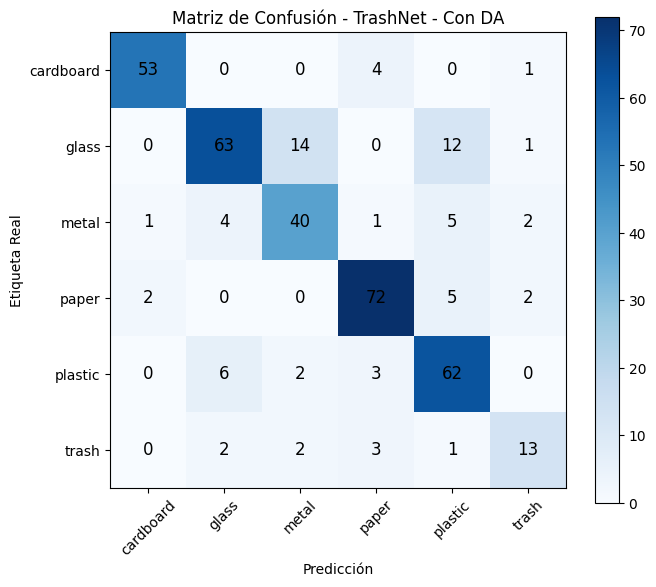

Exactitud global en TEST (TrashNet - Con DA): 0.8059

>> Exactitud TrashNet Sin DA: 0.7821522309711286
>> Exactitud TrashNet Con DA: 0.8058510638297872


In [10]:
# ================================================================
# BLOQUE 8: EVALUACIÓN TRASHNET (CON MATRICES DE CONFUSIÓN)
# ================================================================

print("\n=== EVALUACIÓN TrashNet - SIN DA ===")
acc_tn = evaluar_en_test(
    model_tn,
    test_loader,
    trashnet_full.classes,
    modelo_nombre="TrashNet - Sin DA"
)

print("\n=== EVALUACIÓN TrashNet - CON DA ===")
acc_tn_aug = evaluar_en_test(
    model_tn_aug,
    test_loader_aug,
    trashnet_aug_full.classes,
    modelo_nombre="TrashNet - Con DA"
)

print("\n>> Exactitud TrashNet Sin DA:", acc_tn)
print(">> Exactitud TrashNet Con DA:", acc_tn_aug)

In [11]:
# ================================================================
# BLOQUE 9: Carga de TACO como conjunto de prueba
# ================================================================
print("\nCargando TACO (mismas 6 clases que TrashNet)...")

transform_taco = transforms.ToTensor()

# Se asume que TACO ya fue filtrado a las mismas 6 clases
taco_full = datasets.ImageFolder(taco_dir, transform=transform_taco)

print("Clases detectadas en TACO:", taco_full.classes)

# Puedes usar TODO TACO como test, o dividir (pero no entrenaremos nada)
test_loader_taco = DataLoader(taco_full, batch_size=32, shuffle=False)


Cargando TACO (mismas 6 clases que TrashNet)...
Clases detectadas en TACO: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']



=== Evaluación de TrashNet SIN DA sobre TACO ===

   REPORTES DE EVALUACIÓN - TrashNet SIN DA → TACO

              precision    recall  f1-score   support

   cardboard      0.158     0.341     0.216       232
       glass      0.097     0.223     0.135       247
       metal      0.256     0.555     0.350       517
       paper      0.064     0.427     0.112       218
     plastic      0.712     0.146     0.243      1907
       trash      0.268     0.076     0.118      1253

    accuracy                          0.203      4374
   macro avg      0.259     0.295     0.196      4374
weighted avg      0.435     0.203     0.206      4374



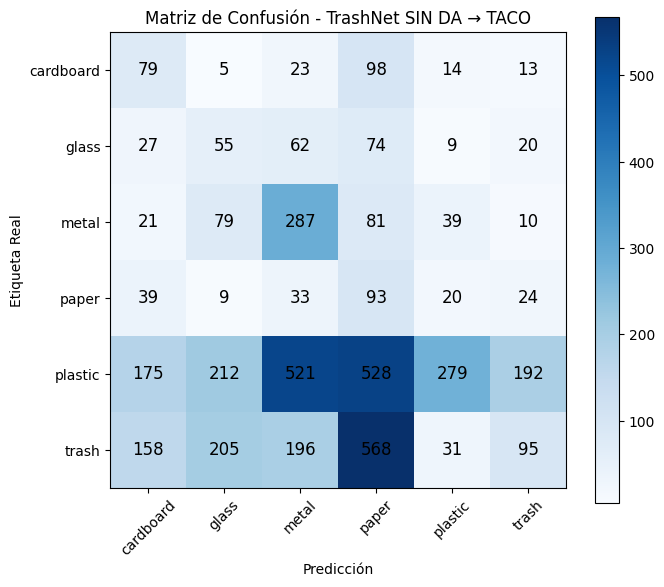

Exactitud global en TEST (TrashNet SIN DA → TACO): 0.2030

Accuracy TACO usando modelo TrashNet SIN DA: 0.2030178326474623


In [13]:
# ================================================================
# BLOQUE 10: Evaluación del modelo sin DA
# ================================================================
print("\n=== Evaluación de TrashNet SIN DA sobre TACO ===")

model_tn.eval()

acc_taco_sinDA =  evaluar_en_test(
    model_tn,
    test_loader_taco,
    taco_full.classes,
    modelo_nombre="TrashNet SIN DA → TACO"
)

print("\nAccuracy TACO usando modelo TrashNet SIN DA:", acc_taco_sinDA)



=== Evaluación de TrashNet CON DA sobre TACO ===

   REPORTES DE EVALUACIÓN - TrashNet con DA → TACO

              precision    recall  f1-score   support

   cardboard      0.158     0.341     0.216       232
       glass      0.097     0.223     0.135       247
       metal      0.256     0.555     0.350       517
       paper      0.064     0.427     0.112       218
     plastic      0.712     0.146     0.243      1907
       trash      0.268     0.076     0.118      1253

    accuracy                          0.203      4374
   macro avg      0.259     0.295     0.196      4374
weighted avg      0.435     0.203     0.206      4374



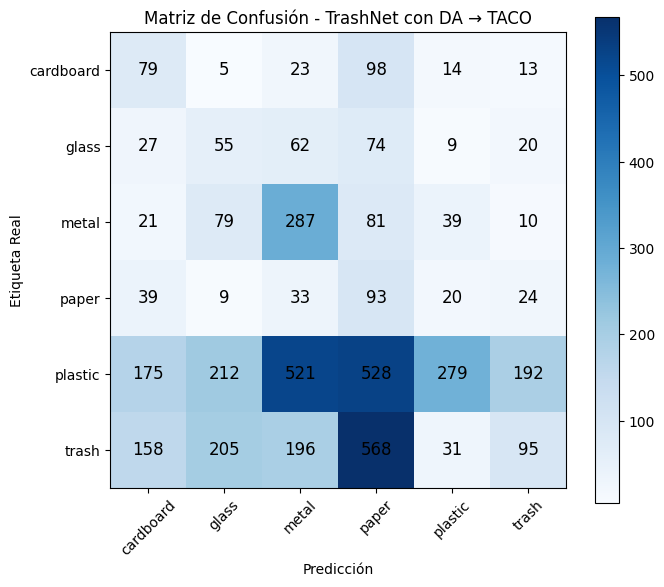

Exactitud global en TEST (TrashNet con DA → TACO): 0.2030

Accuracy TACO usando modelo TrashNet CON DA: 0.2030178326474623


In [ ]:
# ================================================================
# BLOQUE 11: Evaluación del modelo con DA
# ================================================================
print("\n=== Evaluación de TrashNet CON DA sobre TACO ===")

model_tn_aug.eval()

acc_taco_conDA =  evaluar_en_test(
    model_tn_aug,
    test_loader_taco,
    taco_full.classes,
    modelo_nombre="TrashNet con DA → TACO"
)

print("\nAccuracy TACO usando modelo TrashNet CON DA:", acc_taco_conDA)


In [ ]:
# ================================================================
# BLOQUE 9: Guardado de ambos modelos
# ================================================================
torch.save(model_tn.state_dict(),
           os.path.join(output_dir, "resnet18_trashnetS2_sinDA_final.pth"))

torch.save(model_tn_aug.state_dict(),
           os.path.join(output_dir, "resnet18_trashnetS2_conDA_final.pth"))

print("\nModelos guardados correctamente.")


Modelos guardados correctamente.
